In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [2]:
df = pd.read_csv("../data/processed/telco_churn_clean.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [5]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

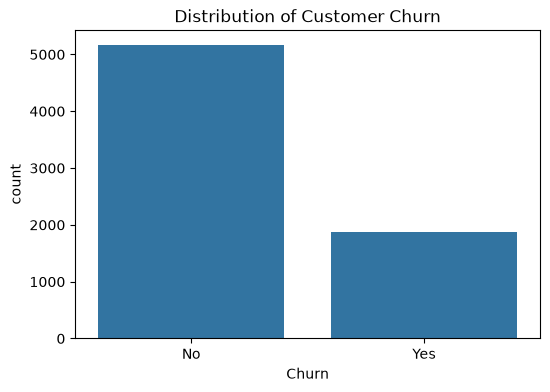

In [6]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Churn")
plt.title("Distribution of Customer Churn")
plt.show()

### Observation

- Majority of customers did not churn.
- The dataset is moderately imbalanced.
- This should be considered during model evaluation.
- Accuracy alone may not be a sufficient evaluation metric; precision, recall, and F1-score should also be considered during model evaluation.

In [7]:
numerical_features = df.select_dtypes(include=["number"]).columns.tolist()
categorical_features = df.select_dtypes(include=["str"]).columns.tolist()

In [8]:
print(df.dtypes.unique())

[<StringDtype(na_value=nan)> dtype('int64') dtype('float64')]


In [9]:
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [10]:
categorical_features

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [11]:
# Remove identifier column
categorical_features.remove("customerID")

# Treat binary variable as categorical
numerical_features.remove("SeniorCitizen")
categorical_features.append("SeniorCitizen")

# Numerical Feature Analysis

This section explores the distribution and characteristics of numerical features in the dataset.

In [12]:
numerical_features

['tenure', 'MonthlyCharges', 'TotalCharges']

In [13]:
df['tenure'].describe()

count    7032.000000
mean       32.421786
std        24.545260
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

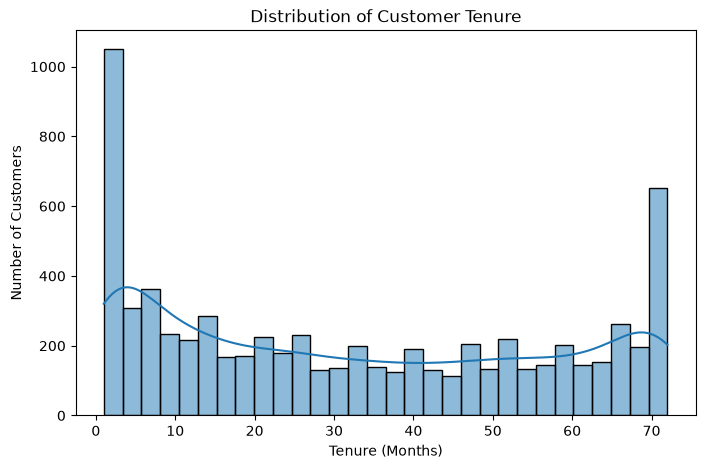

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="tenure", bins=30, kde=True)

plt.title("Distribution of Customer Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.show()

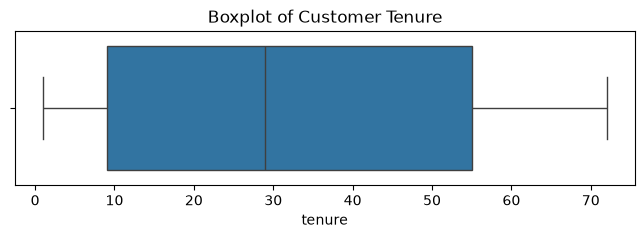

In [15]:
plt.figure(figsize=(8,2))

sns.boxplot(data=df,x="tenure")
plt.title("Boxplot of Customer Tenure")
plt.show()

### Observations

- Customer tenure ranges from 1 to 72 months.
- Most customers have relatively low tenure.
- Another concentration exists near the maximum tenure.
- The distribution is not perfectly symmetric.

In [16]:
df['MonthlyCharges'].describe()

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64

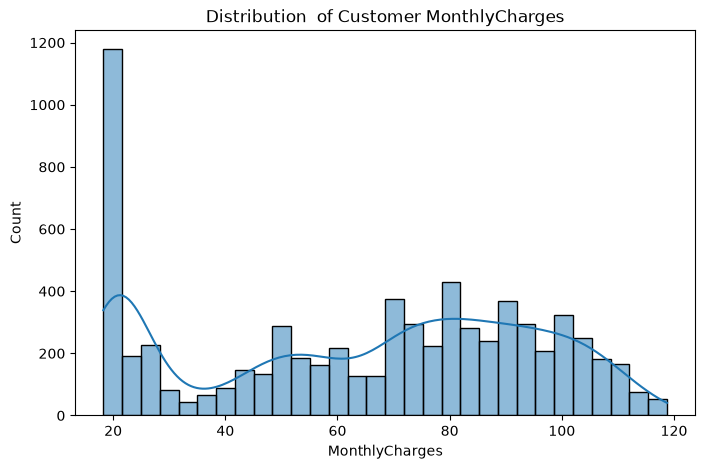

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", bins=30, kde=True)
plt.title("Distribution  of Customer MonthlyCharges")

plt.show()

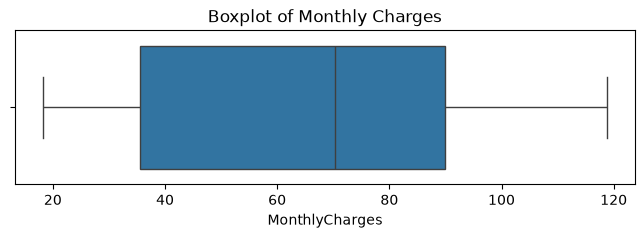

In [18]:
plt.figure(figsize=(8,2))

sns.boxplot(
    data=df,
    x="MonthlyCharges"
)

plt.title("Boxplot of Monthly Charges")
plt.show()

### Observations

- Monthly charges vary across a wide range.
- The distribution is slightly skewed.
- The boxplot does not indicate a large number of extreme outliers.
- Most customers fall within the central range of monthly charges.

In [19]:
df["TotalCharges"].describe()

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
25%       401.450000
50%      1397.475000
75%      3794.737500
max      8684.800000
Name: TotalCharges, dtype: float64

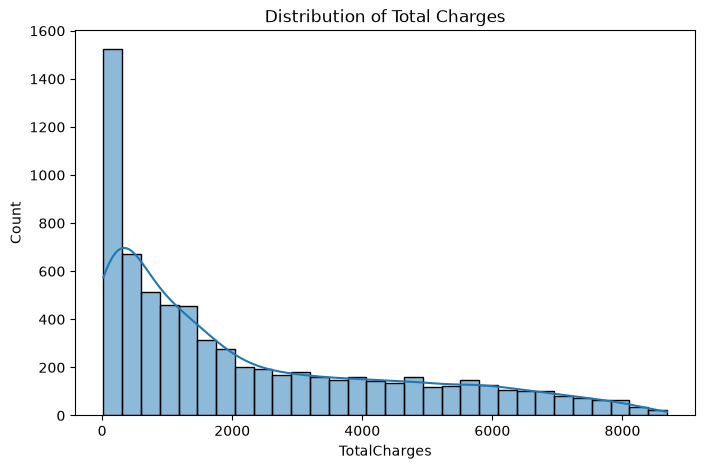

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df, x="TotalCharges", bins=30,
    kde=True
)

plt.title("Distribution of Total Charges")
plt.show()

### Observations

- Total charges exhibit a wide spread among customers.
- The distribution is positively skewed.
- Higher total charges are observed for a smaller number of customers.
- A few high-value observations appear in the boxplot.

# 3. Categorical Feature Analysis

In this section, we examine the distribution of important categorical features to understand customer demographics, service usage, and subscription characteristics.

In [21]:
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn',
 'SeniorCitizen']

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df['gender'].value_counts()

gender
Male      3549
Female    3483
Name: count, dtype: int64

In [24]:
(df["gender"].value_counts(normalize=True) * 100).round(2)

gender
Male      50.47
Female    49.53
Name: proportion, dtype: float64

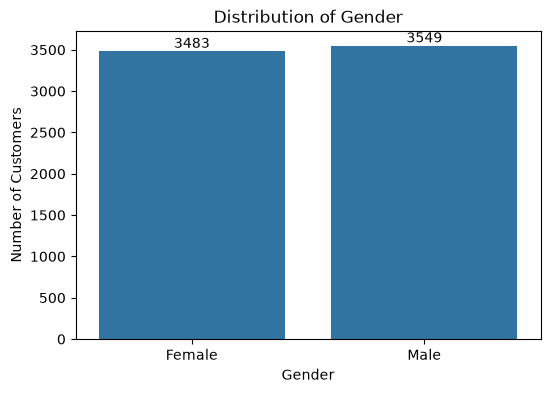

In [25]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="gender")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Male and female customers are almost equally represented.
- No significant gender imbalance is observed.

In [26]:
df['SeniorCitizen_Label'] = df['SeniorCitizen'].map( {0: 'No', 1: 'Yes'} )

In [27]:
df['SeniorCitizen_Label'].value_counts(normalize=True) * 100

SeniorCitizen_Label
No     83.759954
Yes    16.240046
Name: proportion, dtype: float64

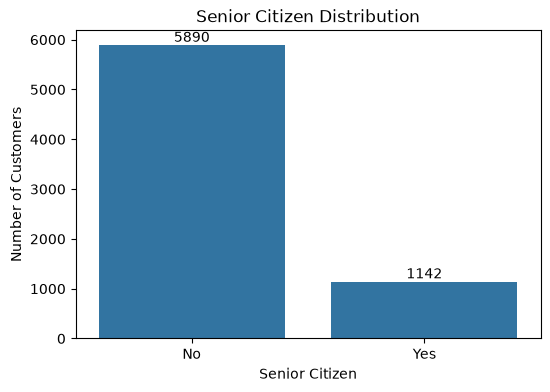

In [28]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="SeniorCitizen_Label")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen Distribution")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Most customers are not senior citizens.
- Senior citizens represent a smaller proportion of the customer base.

In [29]:
df['Partner'].value_counts()

Partner
No     3639
Yes    3393
Name: count, dtype: int64

In [30]:
df['Partner'].value_counts(normalize=True) * 100

Partner
No     51.749147
Yes    48.250853
Name: proportion, dtype: float64

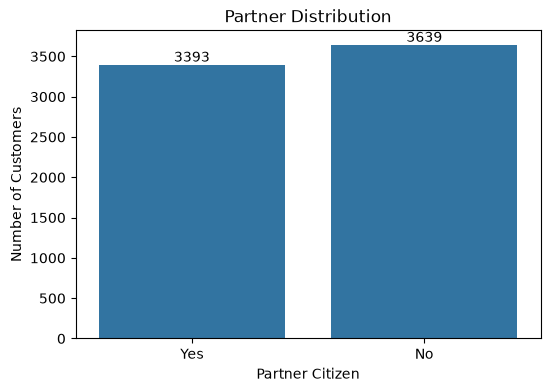

In [31]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Partner")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Partner Distribution")
plt.xlabel("Partner Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Partner - yes or No are almost equally represented.
- No significant Partner imbalance is observed.

In [32]:
df['Dependents'].value_counts(normalize=True) * 100

Dependents
No     70.150739
Yes    29.849261
Name: proportion, dtype: float64

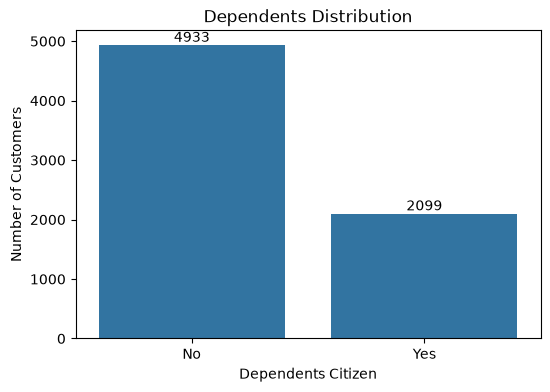

In [33]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Dependents")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Dependents Distribution")
plt.xlabel("Dependents Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Most customers are in not Dependent Category.

In [34]:
df["InternetService"].value_counts()

InternetService
Fiber optic    3096
DSL            2416
No             1520
Name: count, dtype: int64

In [35]:
(df["InternetService"].value_counts(normalize=True) * 100)

InternetService
Fiber optic    44.027304
DSL            34.357224
No             21.615472
Name: proportion, dtype: float64

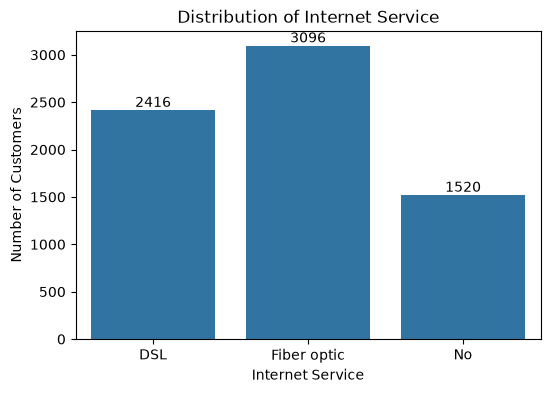

In [36]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="InternetService")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- DSL and Fiber optics are main internet services
- a smaller group of customers has no internet services

In [37]:
df["Contract"].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [38]:
df["Contract"].value_counts(normalize=True) * 100

Contract
Month-to-month    55.105233
Two year          23.961889
One year          20.932878
Name: proportion, dtype: float64

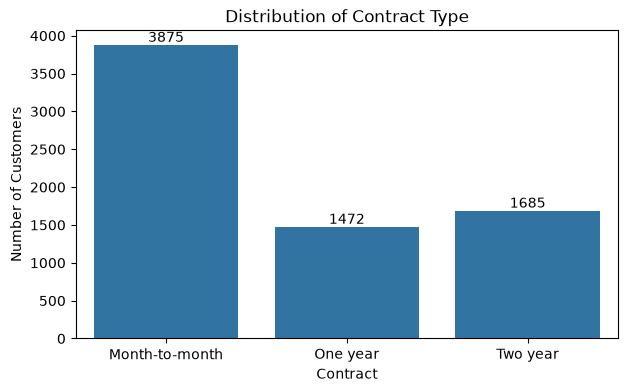

In [39]:
plt.figure(figsize=(7,4))

ax = sns.countplot(
    data=df,
    x="Contract"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Most of the customers have Month to Month contract 
- Then some has One year and some group has 2 year Contract

In [40]:
df['PaperlessBilling'].value_counts(normalize=True) * 100

PaperlessBilling
Yes    59.2719
No     40.7281
Name: proportion, dtype: float64

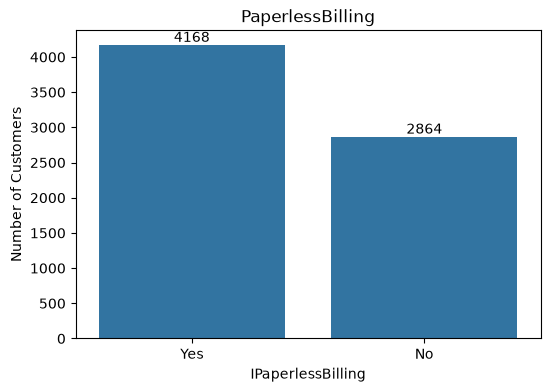

In [41]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="PaperlessBilling")

for container in ax.containers:
    ax.bar_label(container)

plt.title("PaperlessBilling")
plt.xlabel("IPaperlessBilling")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Approximately **59.27%** of customers use paperless billing, while **40.72%** do not.
- Paperless billing is more commonly used among customers in the dataset.
- The distribution indicates a moderate preference for paperless billing over traditional billing methods.

In [42]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1604
Bank transfer (automatic)    1542
Credit card (automatic)      1521
Name: count, dtype: int64

In [43]:
df['PaymentMethod'].value_counts(normalize=True) * 100

PaymentMethod
Electronic check             33.631968
Mailed check                 22.810011
Bank transfer (automatic)    21.928328
Credit card (automatic)      21.629693
Name: proportion, dtype: float64

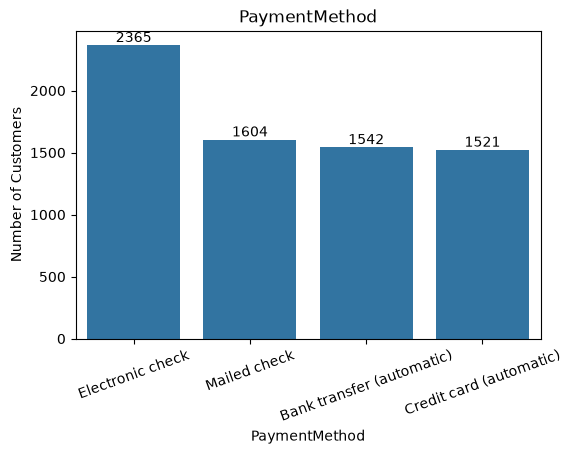

In [44]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="PaymentMethod")

for container in ax.containers:
    ax.bar_label(container)

plt.title("PaymentMethod")
plt.xticks(rotation=20)
plt.xlabel("PaymentMethod")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Electronic check is the most common method and then others are almost same 

In [45]:
#Bivariate Analysis

pd.crosstab(df["gender"], df["Churn"])

Churn,No,Yes
gender,,
Female,2544,939
Male,2619,930


In [46]:
pd.crosstab(df["gender"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
gender,,
Female,73.0,27.0
Male,73.8,26.2


<Axes: xlabel='gender', ylabel='count'>

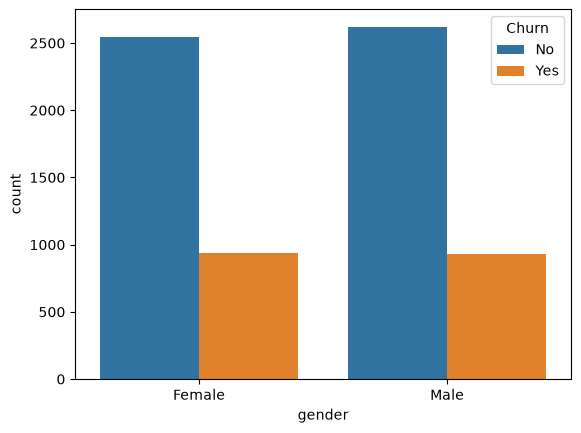

In [47]:
sns.countplot(data=df, x="gender", hue="Churn")

### Observations

- Approximately **26.2%** of female customers and **26.1%** of male customers churned.
- The churn rates are nearly identical across both genders.
- This suggests that gender is unlikely to be a major factor influencing customer churn.

In [48]:
pd.crosstab(df["SeniorCitizen_Label"], df["Churn"])

Churn,No,Yes
SeniorCitizen_Label,,
No,4497,1393
Yes,666,476


In [49]:
pd.crosstab(df["SeniorCitizen_Label"], df["Churn"], normalize="index").round(3) * 100

Churn,No,Yes
SeniorCitizen_Label,,
No,76.3,23.7
Yes,58.3,41.7


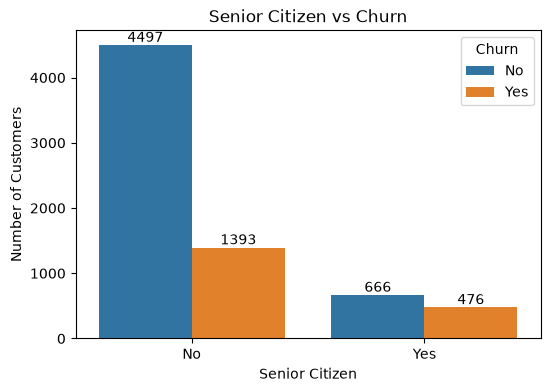

In [50]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="SeniorCitizen_Label",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Senior Citizen vs Churn")
plt.xlabel("Senior Citizen")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Senior citizen customers have a noticeably higher churn rate than non-senior customers.
- Although senior citizens make up a smaller portion of the customer base, they are more likely to discontinue the service.
- Senior citizen status appears to be associated with customer churn.

In [51]:
pd.crosstab(df["Partner"], df["Churn"])

Churn,No,Yes
Partner,,
No,2439,1200
Yes,2724,669


In [52]:
pd.crosstab(df["SeniorCitizen_Label"], df["Churn"], normalize="index").round(2) * 100

Churn,No,Yes
SeniorCitizen_Label,,
No,76.0,24.0
Yes,58.0,42.0


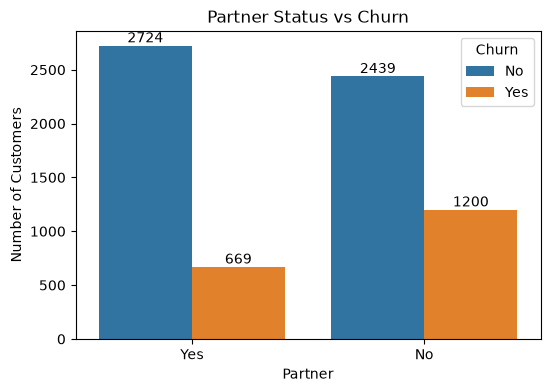

In [53]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Partner Status vs Churn")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Customers without a partner have a higher churn rate than customers with a partner.
- Customers with a partner tend to remain with the company for a longer period.
- Having a partner appears to be associated with lower customer churn.

In [56]:
pd.crosstab(df['Dependents'], df['Churn'])

Churn,No,Yes
Dependents,,
No,3390,1543
Yes,1773,326


In [59]:
pd.crosstab(df['Dependents'], df['Churn'], normalize='index').round(4) * 100

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.47,15.53


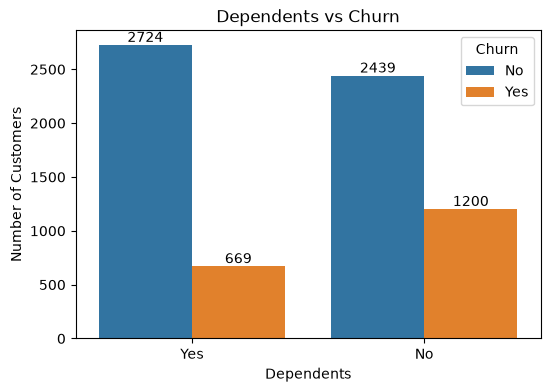

In [67]:
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df, x="Partner", hue="Churn")

for container in ax.containers:
    ax.bar_label(container)

plt.title("Dependents vs Churn")
plt.xlabel("Dependents")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Approximately **31.28%** of customers without dependents churned, compared to only **15.51%** of customers with dependents.
- Customers with dependents have a substantially lower churn rate than customers without dependents.
- This suggests that the presence of dependents is associated with greater customer retention.

In [60]:
pd.crosstab(df["InternetService"], df["Churn"])

Churn,No,Yes
InternetService,,
DSL,1957,459
Fiber optic,1799,1297
No,1407,113


In [61]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index').round(4) * 100

Churn,No,Yes
InternetService,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


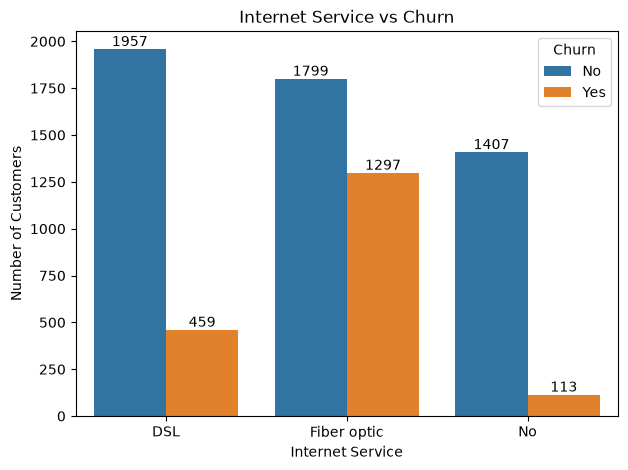

In [62]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Internet Service vs Churn")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.show()

### Observations

- Customers using **Fiber optic** internet service have the highest churn rate (**41.89%**) among all internet service types.
- Customers with **DSL** service have a considerably lower churn rate (**19.00%**) compared to Fiber optic users.
- Customers without an internet service have the lowest churn rate (**7.43%**), indicating they are the least likely to leave the company.
- The type of internet service appears to be strongly associated with customer churn, with Fiber optic customers showing the greatest likelihood of churning.

In [63]:
pd.crosstab(df['Contract'], df["Churn"])

Churn,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [64]:
pd.crosstab(df['Contract'], df["Churn"], normalize='index').round(4) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


### Observations

- Customers with **month-to-month contracts** have the highest churn rate (**42.71%**).
- Customers with **one-year contracts** have a significantly lower churn rate (**11.28%**) compared to month-to-month customers.
- Customers with **two-year contracts** have the lowest churn rate (**2.85%**), indicating the highest customer retention.
- As the contract duration increases, the churn rate decreases substantially.
- Contract type appears to be one of the strongest factors associated with customer churn in the dataset.

In [65]:
pd.crosstab(df['PaperlessBilling'], df["Churn"])

Churn,No,Yes
PaperlessBilling,,
No,2395,469
Yes,2768,1400


In [66]:
pd.crosstab(df['PaperlessBilling'], df["Churn"], normalize='index').round(4) * 100

Churn,No,Yes
PaperlessBilling,,
No,83.62,16.38
Yes,66.41,33.59


### Observations

- Customers using **paperless billing** have a higher churn rate (**33.59%**) than customers who do not use paperless billing (**16.38%**).
- Customers who do not use paperless billing exhibit a comparatively lower churn rate and higher retention.
- Paperless billing appears to be associated with an increased likelihood of customer churn.

In [68]:
pd.crosstab(df['PaymentMethod'], df['Churn'])

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),1284,258
Credit card (automatic),1289,232
Electronic check,1294,1071
Mailed check,1296,308


In [69]:
pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index').round(4) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


### Observations

- Customers using **Electronic check** have the highest churn rate (**45.29%**) among all payment methods.
- Customers using **Credit card (automatic)** have the lowest churn rate (**15.25%**), followed closely by **Bank transfer (automatic)** (**16.73%**).
- Customers paying through **Mailed check** have a moderate churn rate (**19.20%**), which is higher than automatic payment methods but much lower than Electronic check.
- Automatic payment methods are associated with lower churn rates, while Electronic check users are considerably more likely to churn.
- Payment method appears to be an important factor associated with customer churn.

### Numerical Features VS Churn

In [70]:
df.groupby("Churn")["tenure"].describe().round(2)

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.65,24.08,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


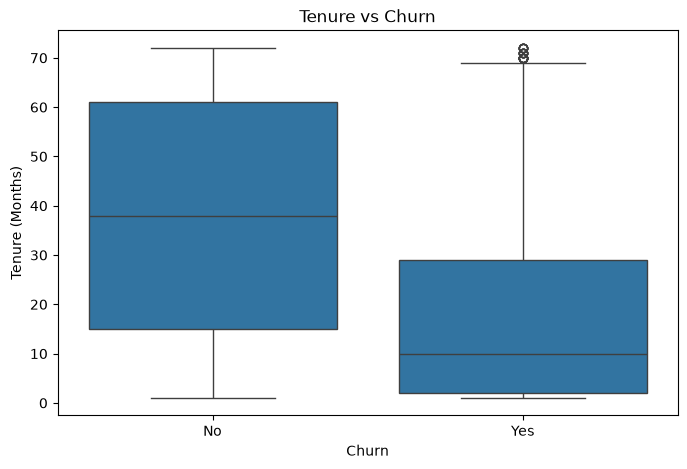

In [71]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

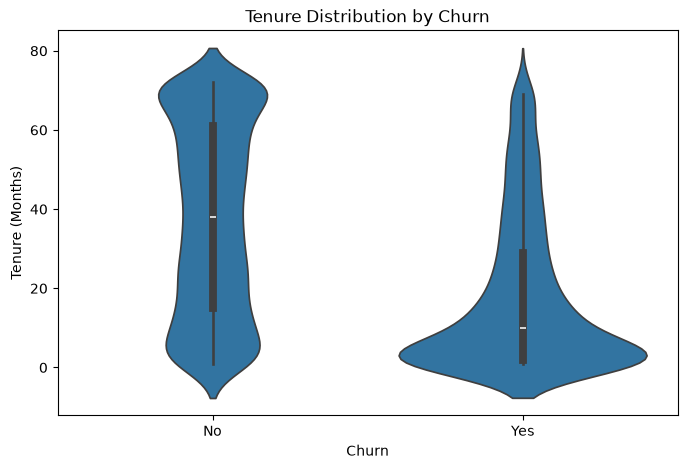

In [72]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

### Observations

- Customers who churned have a substantially lower average tenure (**17.98 months**) compared to customers who remained with the company (**37.65 months**).
- The median tenure of churned customers is **10 months**, whereas the median tenure of retained customers is **38 months**, indicating that many customers leave during the early stages of their subscription.
- Customers with longer service tenure are generally less likely to churn.
- Tenure appears to be one of the strongest numerical features associated with customer churn.